CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [2]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

In [4]:
for batch in train_loader:
    print(batch[0].shape)
    print(batch[1])
    break  # 리스트로 저장. 리스트의 0번쨰 원소는

torch.Size([64, 1, 28, 28])
tensor([4, 1, 4, 9, 1, 1, 4, 7, 5, 9, 3, 8, 6, 3, 2, 4, 1, 1, 0, 8, 4, 6, 0, 7,
        6, 8, 7, 4, 3, 7, 6, 4, 8, 2, 8, 0, 1, 3, 0, 9, 5, 3, 7, 1, 1, 9, 7, 7,
        2, 9, 5, 7, 4, 2, 0, 9, 4, 2, 1, 7, 5, 1, 9, 8])


모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# 모델 인스턴스 생성
model = myCNN()
model.to(device)

# 손실 함수 생성
criterion = nn.CrossEntropyLoss() # 10 Class classification.. CE loss 활용

# optimizer

optimizer = optim.Adam(model.parameters(), lr = 1e-3)

cuda


모델 학습 ✅

In [6]:
# 학습 루프
train_losses = []
test_losses = []
test_accuracies = []

num_epochs = 10

for epoch in range(num_epochs):
    model.train()

    train_loss = 0
    for batch in train_loader:
        data, target = batch
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target) #
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader) # 미니배치의 평균 loss 계산
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}')
    train_losses.append(train_loss)
    break # 1 에폭만 돌림..


Epoch 1/10, Train Loss: 0.1351


모델 평가 ✅

In [7]:
# 평가. test set

model.eval()
correct = 0
total = 0

with torch.no_grad(): # 그라디언트 자동 미분 꺼서, 속도 빠르게 (test set)
    for batch in test_loader:
        data, target = batch
        data = data.to(device)
        target = target.to(device)

        output = model(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)

test_acc = correct / total
test_accuracies.append(test_acc)
print(f'Test Acc. : {test_acc}')


Test Acc. : 0.9867


10회 반복 시행 ✅

In [8]:
num_epochs = 9

for epoch in range(num_epochs):
    model.train()

    train_loss = 0
    test_loss = 0
    for batch in train_loader:
        data, target = batch
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target) #
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader) # 미니배치의 평균 loss 계산
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}')
    train_losses.append(train_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad(): # 그라디언트 자동 미분 꺼서, 속도 빠르게 (test set)
        for batch in test_loader:
            data, target = batch
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    test_acc = correct / total
    test_accuracies.append(test_acc)
    print(f'Epoch {epoch+1}/{num_epochs}, Test Acc. : {test_acc}')


Epoch 1/9, Train Loss: 0.0378
Test Acc. : 0.991
Epoch 2/9, Train Loss: 0.0275
Test Acc. : 0.9872
Epoch 3/9, Train Loss: 0.0201
Test Acc. : 0.9897
Epoch 4/9, Train Loss: 0.0169
Test Acc. : 0.9926
Epoch 5/9, Train Loss: 0.0131
Test Acc. : 0.9922
Epoch 6/9, Train Loss: 0.0116
Test Acc. : 0.9928
Epoch 7/9, Train Loss: 0.0121
Test Acc. : 0.9926
Epoch 8/9, Train Loss: 0.0093
Test Acc. : 0.9934
Epoch 9/9, Train Loss: 0.0095
Test Acc. : 0.9931


결과 시각화

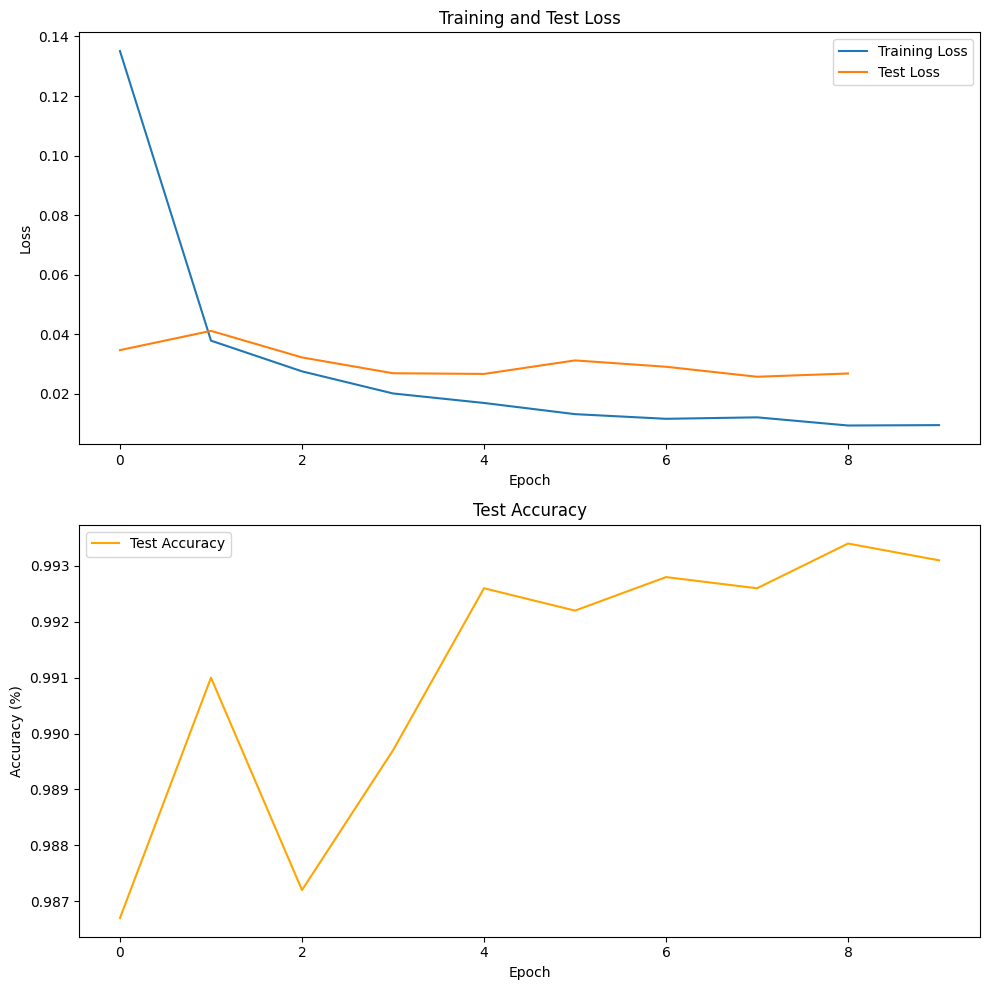

In [9]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(test_accuracies, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()